<a href="https://colab.research.google.com/github/MaAlejandraM/Parcial_2_programacion_ciencia_datos/blob/main/probando_ev_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial N°2

## Integrantes:

*   Maria Alejandra Marambio
*   Pamela Toro

### Fecha: Martes 19 de mayo, 2026.-

# 1. Importar las librerías a utilizar

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y evaluación
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score, roc_auc_score

# Configuración de reproducibilidad (Seed)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 2. Cargar los datos en un dataframe original y en el dataframe a utilizar.

In [2]:
df_original = pd.read_csv('neo.csv')
df = df_original.copy()

# 3. Preparación y análisis exploratorio de datos.

In [3]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [4]:
df.shape

(90836, 10)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,90836.0,1.438288e+07,2.087202e+07,2.000433e+06,3.448110e+06,3.748362e+06,3.884023e+06,5.427591e+07
est_diameter_min,90836.0,1.274321e-01,2.985112e-01,6.089126e-04,1.925551e-02,4.836765e-02,1.434019e-01,3.789265e+01
est_diameter_max,90836.0,2.849469e-01,6.674914e-01,1.361570e-03,4.305662e-02,1.081534e-01,3.206564e-01,8.473054e+01
relative_velocity,90836.0,4.806692e+04,2.529330e+04,2.033464e+02,2.861902e+04,4.419012e+04,6.292360e+04,2.369901e+05
miss_distance,90836.0,3.706655e+07,2.235204e+07,6.745533e+03,1.721082e+07,3.784658e+07,5.654900e+07,7.479865e+07
absolute_magnitude,90836.0,2.352710e+01,2.894086e+00,9.230000e+00,2.134000e+01,2.370000e+01,2.570000e+01,3.320000e+01


In [6]:
df.describe(include='O').T

,count,unique,top,freq
name,90836,27423,277810 (2006 FV35),43
orbiting_body,90836,1,Earth,90836


In [7]:
df.columns


Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object',
       'absolute_magnitude', 'hazardous'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


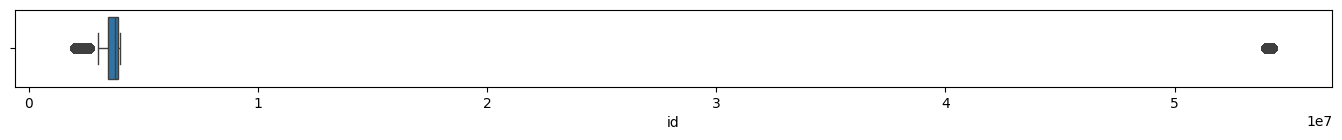

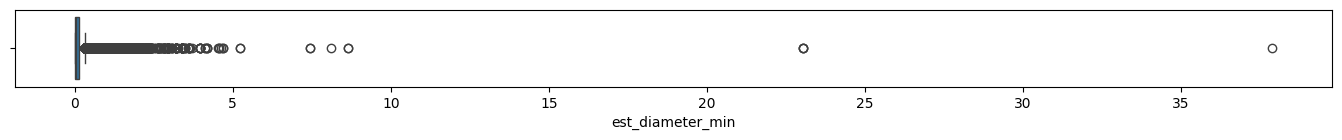

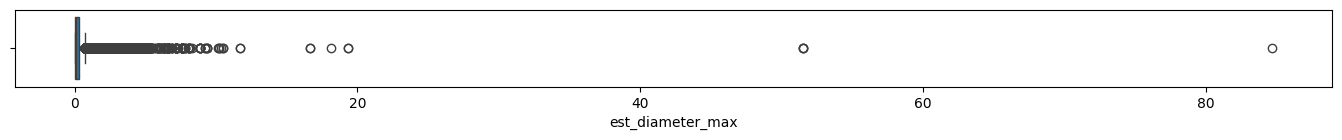

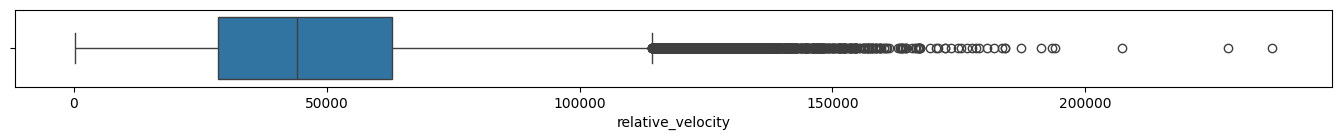

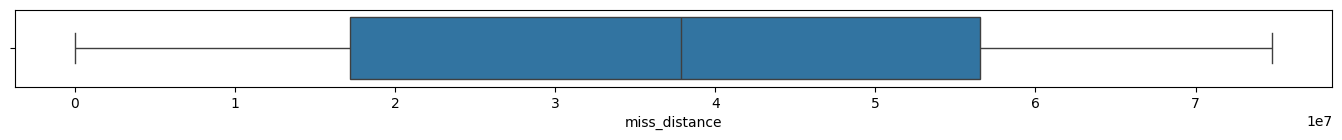

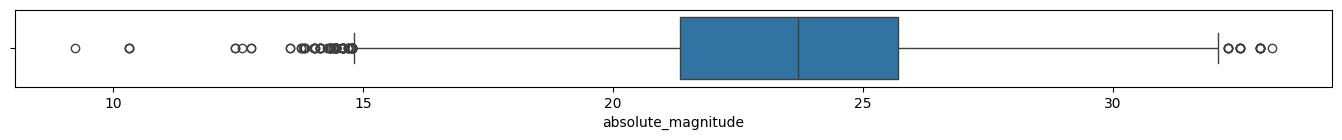

In [9]:
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=df[num_cols], x=col)

In [10]:
print("Valores nulos por columnas")
print(df.isnull().sum())

Valores nulos por columnas
id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64


In [11]:
# Datos duplicados:
df.duplicated().sum()

np.int64(0)

/tmp/ipykernel_7749/957243439.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis', ax=axes[i])
/tmp/ipykernel_7749/957243439.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis', ax=axes[i])
/tmp/ipykernel_7749/957243439.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis', ax=axes[i])


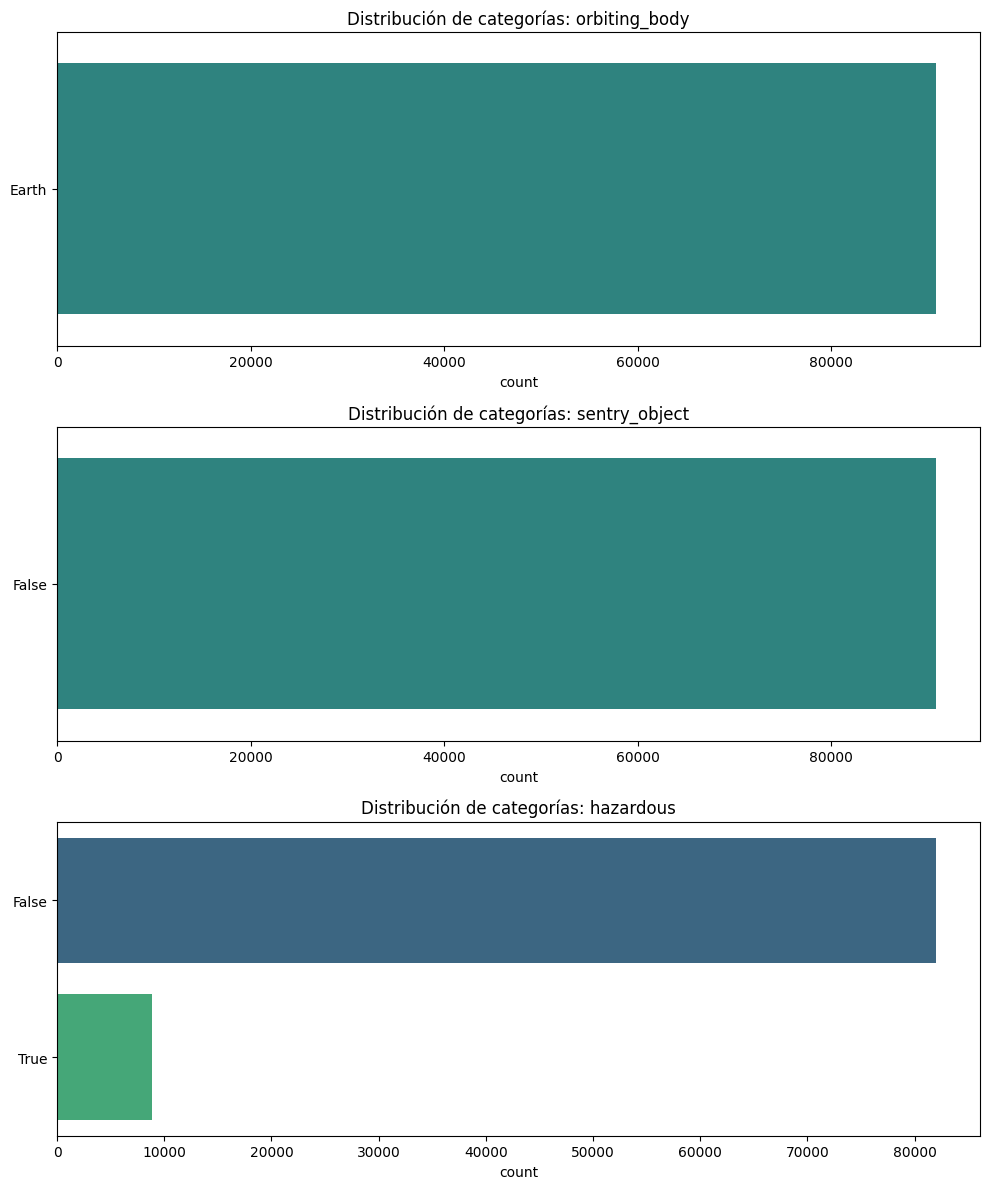

In [12]:
categoricas = ['orbiting_body', 'sentry_object', 'hazardous']

# Create a single figure with subplots arranged vertically
fig, axes = plt.subplots(nrows=len(categoricas), ncols=1, figsize=(10, 4 * len(categoricas)))

# Ensure axes is an array even if there's only one subplot
if len(categoricas) == 1:
    axes = [axes]

for i, col in enumerate(categoricas):
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Distribución de categorías: {col}')
    axes[i].set_ylabel('') # Remove y-axis label to avoid redundancy

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

* al solo estar el planeta Tierra, se puede obviar esta variable.

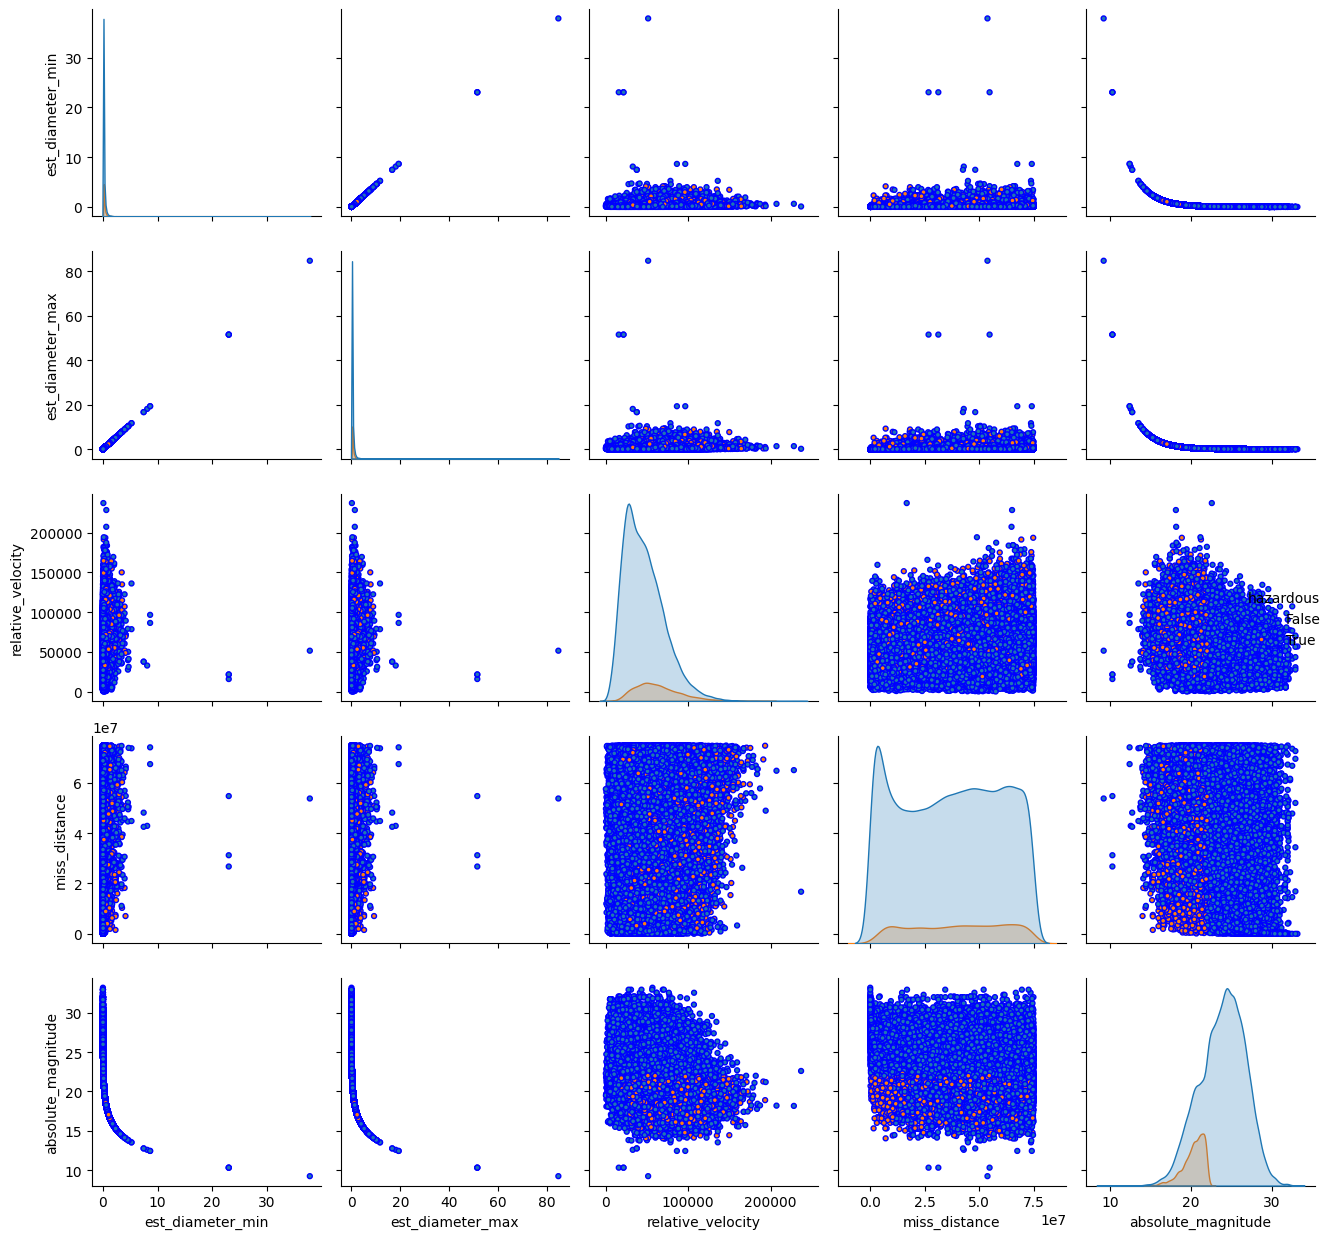

In [13]:
sns.pairplot(data=df,
             diag_kind="kde",
             markers=".",
             plot_kws=dict(s=50, edgecolor="b", linewidth=1),
             hue="hazardous",
             vars=["est_diameter_min",
                   "est_diameter_max",
                   "relative_velocity",
                   "miss_distance",
                   "absolute_magnitude"])

plt.tight_layout()
plt.show()

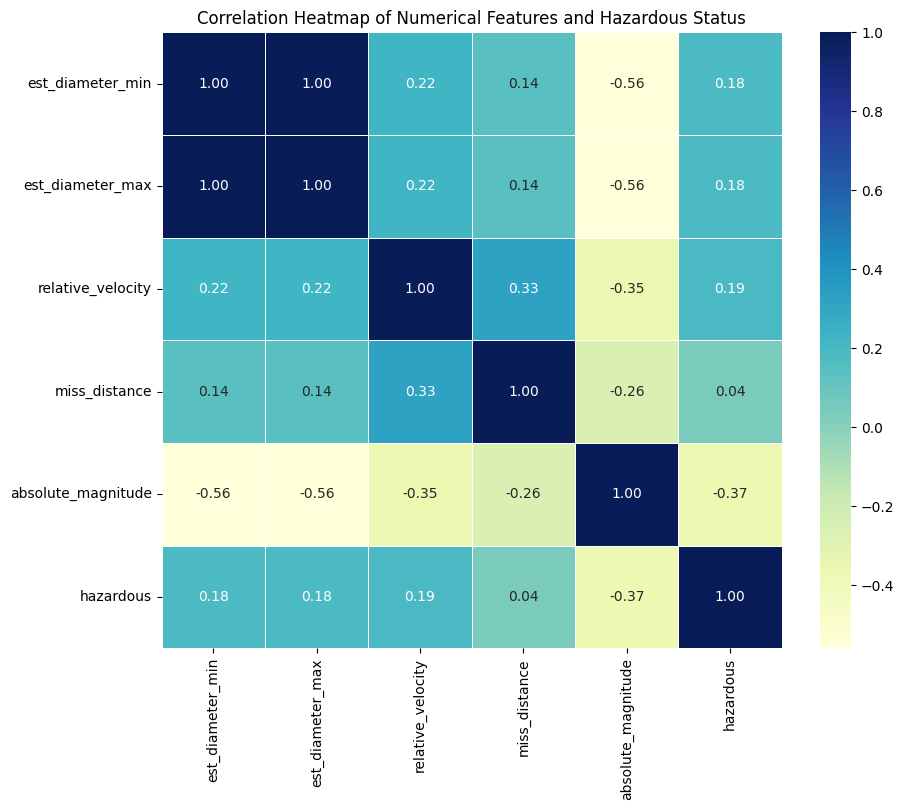

In [14]:
df_for_corr = df.copy()

df_for_corr.dropna(subset=['hazardous', 'absolute_magnitude'], inplace=True)

df_for_corr['hazardous'] = df_for_corr['hazardous'].astype(int)

numerical_and_target_cols = [
    'est_diameter_min', 'est_diameter_max', 'relative_velocity',
    'miss_distance', 'absolute_magnitude', 'hazardous'
]

correlation_matrix = df_for_corr[numerical_and_target_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="YlGnBu", linewidths=.5, annot=True, fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features and Hazardous Status')
plt.show()

##Distribucion de la variable objetivo

In [15]:
print(df['hazardous'].value_counts())

hazardous
False    81996
True      8840
Name: count, dtype: int64


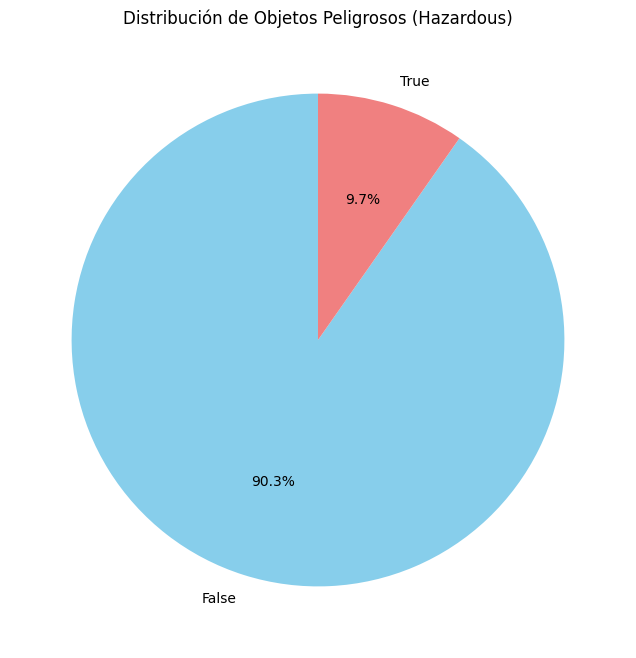

In [16]:
hazardous_counts = df['hazardous'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(hazardous_counts, labels=hazardous_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribución de Objetos Peligrosos (Hazardous)')
plt.show()

Nuestro conjunto de datos no parece muy equilibrado. Vamos a equilibrarlo con el método de sobremuestreo (Upsampling).

In [17]:
from sklearn.utils import resample

df_upsample = df.copy()

# Convertir 'hazardous' a entero para remuestreo (False=0, True=1)
df_upsample['hazardous'] = df_upsample['hazardous'].astype(int)

df_majority = df_upsample[df_upsample['hazardous'] == 0]
df_minority = df_upsample[df_upsample['hazardous'] == 1]

# Aumentar el tamaño de la muestra de la clase minoritaria para que coincida con el tamaño de la clase mayoritaria.
df_minority_upsampled = resample(df_minority,
                                 replace=True,  # Muestra con reemplazo
                                 n_samples=len(df_majority),  # Para que coincida con el tamaño de la clase mayoritaria.
                                 random_state=RANDOM_STATE)

# Concatenar la clase mayoritaria con la clase minoritaria sobremuestreada.
df_balanced = pd.concat([df_majority, df_minority_upsampled])

print(" conjunto de datos equilibrado:", df_balanced.shape)
print("Hazardous distribución después del sobremuestreo:")
print(df_balanced['hazardous'].value_counts())

 conjunto de datos equilibrado: (163992, 10)
Hazardous distribución después del sobremuestreo:
hazardous
0    81996
1    81996
Name: count, dtype: int64


# Versión Actual:

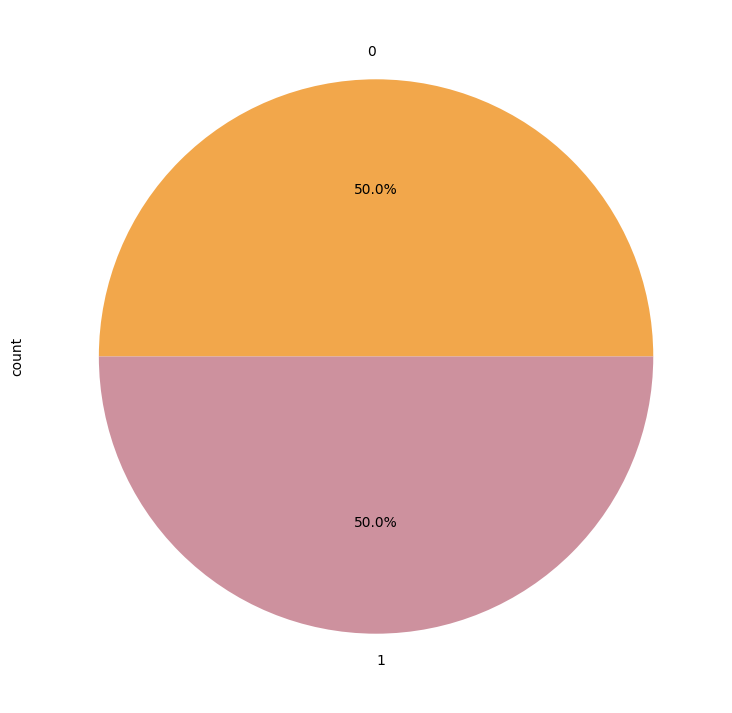

hazardous
0    81996
1    81996
Name: count, dtype: int64


In [18]:
df_balanced['hazardous'].value_counts().plot(kind='pie',colors=['#F2A74B', '#cd919e'],autopct='%1.1f%%',figsize=(9,9))
plt.show()
varValue = df_balanced.hazardous.value_counts()
print(varValue)

Estandarización de las variables numéricas
Aplicaremos StandardScaler a las columnas numéricas relevantes para preparar los datos para el modelado. Esto es importante para algoritmos que son sensibles a la escala de las características, como KMeans o modelos basados en distancia.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Reinicializa df desde df_original para asegurarte de que todas las columnas estén presentes.
df = df_original.copy()

# Aplicar LabelEncoder a la columna 'hazardous'
#Esto garantiza que la palabra 'hazardous' se codifique antes de que se escalen las demás columnas numéricas.
le = LabelEncoder()
df['hazardous'] = le.fit_transform(df['hazardous'])

# Identificar las columnas numéricas a estandarizar
# Excluyendo 'id' que es un identificador y 'hazardous' que es la variable objetivo binaria
numerical_cols_to_scale = ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplicar la estandarización a las columnas seleccionadas
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print("DataFrame después de estandarizar las columnas numéricas:")
display(df.head())

DataFrame después de estandarizar las columnas numéricas:


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),3.587284,3.587284,-1.363913,0.795153,Earth,False,-2.348632,0
1,2277475,277475 (2005 WK4),0.463529,0.463529,1.009040,1.090357,Earth,False,-1.218735,1
2,2512244,512244 (2015 YE18),1.991887,1.991887,2.616983,0.569624,Earth,False,-1.968544,0
3,3596030,(2012 BV13),-0.103601,-0.103601,-0.921301,-0.520384,Earth,False,-0.458560,0
4,3667127,(2014 GE35),0.427378,0.427378,-0.210697,0.412001,Earth,False,-1.187637,1


Codificación por LabelEncoder la variable Hazardous

In [20]:
# Instanciar el codificador
le = LabelEncoder()

# Ajustar y transformar la columna objetivo
df['hazardous'] = le.fit_transform(df['hazardous'])

# Separar la variable objetivo
y = df['hazardous']

# Tip técnico para la presentación: puedes verificar qué número le tocó a cada clase
print("Clases identificadas:", le.classes_) # Retornará [False, True], mapeados a [0, 1]


Clases identificadas: [0 1]


decidir que variables no vamos a usar en el dataframe: id, name, orbiting_body, sentry_object

In [21]:
cols_to_drop = ['id','name', 'orbiting_body', 'sentry_object']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("DataFrame después de eliminar columnas:")
display(df.head())

DataFrame después de eliminar columnas:


,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,3.587284,3.587284,-1.363913,0.795153,-2.348632,0
1,0.463529,0.463529,1.009040,1.090357,-1.218735,1
2,1.991887,1.991887,2.616983,0.569624,-1.968544,0
3,-0.103601,-0.103601,-0.921301,-0.520384,-0.458560,0
4,0.427378,0.427378,-0.210697,0.412001,-1.187637,1


¿Por qué eliminamos estas exactamente?

En ciencia de datos, nos basamos en dos criterios técnicos que puedes mencionar en tu presentación:

Falta de Poder Predictivo: id y name son etiquetas administrativas. Si las dejas, un modelo (como un Árbol de Decisión) podría intentar encontrar reglas falsas basadas en un número de identificación.

Varianza Cero: Al revisar el archivo neo.csv, notarás que orbiting_body siempre es "Earth" y sentry_object siempre es "False".

Si una variable no cambia, no ayuda al modelo a distinguir entre un objeto peligroso (hazardous = True) y uno que no lo es.

Tip para tu evaluación (SCY1101):
En tu informe o defensa, justifica esta eliminación diciendo:

"Se realizó un filtrado de características (Feature Selection) eliminando variables constantes y de identificación para reducir el ruido y mejorar la eficiencia computacional de los modelos supervisados."

# 4. Modelado supervisado (al menos un modelo)

Regresion logistica

--- Ejecutando Validación Cruzada (5 Pliegues) ---
ACCURACY promedio en CV: 0.7840 (+/- 0.0018)
PRECISION promedio en CV: 0.3021 (+/- 0.0016)
RECALL promedio en CV: 0.9306 (+/- 0.0075)
F1 promedio en CV: 0.4561 (+/- 0.0021)
ROC_AUC promedio en CV: 0.8749 (+/- 0.0027)

--- INFORME DE CLASIFICACIÓN FINAL (TEST SET) ---
              precision    recall  f1-score   support

           0       0.99      0.77      0.87     16400
           1       0.30      0.93      0.46      1768

    accuracy                           0.79     18168
   macro avg       0.65      0.85      0.66     18168
weighted avg       0.92      0.79      0.83     18168



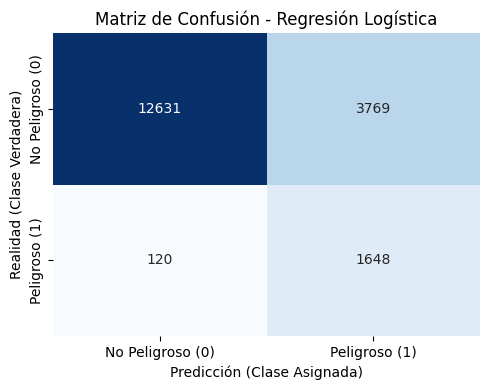

In [22]:
# 1. Configuración de Reproducibilidad (Semilla global)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Separar características (X) y variable objetivo codificada (y)
X = df.drop(columns=['id', 'name', 'orbiting_body', 'sentry_object', 'hazardous'], errors='ignore')
y = df['hazardous'].astype(int)

# Separar en conjuntos de entrenamiento y prueba (Estratificado por el desbalance de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 2. Pipeline de Preprocesamiento Técnico
# Identificar columnas numéricas automáticamente
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Robustez ante nulos
    ('scaler', StandardScaler())                  # Vital para la convergencia de la Regresión Logística
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, num_features)]
)

# 3. Definición del Pipeline del Modelo (Regresión Logística)
# Nota: Usamos class_weight='balanced' para combatir el fuerte desbalance de asteroides peligrosos
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

# 4. Validación Cruzada Robusta
# Evaluamos usando múltiples métricas simultáneamente según la pauta
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("--- Ejecutando Validación Cruzada (5 Pliegues) ---")
cv_results = cross_validate(
    pipeline_lr, X_train, y_train, cv=5, scoring=scoring_metrics, return_train_score=False
)

# Mostrar resultados promedio de la Validación Cruzada
for metric in scoring_metrics:
    mean_score = cv_results[f'test_{metric}'].mean()
    std_score = cv_results[f'test_{metric}'].std()
    print(f"{metric.upper()} promedio en CV: {mean_score:.4f} (+/- {std_score:.4f})")

# 5. Entrenamiento Final y Evaluación con el Conjunto de Prueba (Test Set)
pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)
y_proba = pipeline_lr.predict_proba(X_test)[:, 1]

# Informe de Clasificación Técnico
print("\n--- INFORME DE CLASIFICACIÓN FINAL (TEST SET) ---")
print(classification_report(y_test, y_pred))

# 6. Visualización Clave: Matriz de Confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción (Clase Asignada)')
plt.ylabel('Realidad (Clase Verdadera)')
plt.xticks([0.5, 1.5], ['No Peligroso (0)', 'Peligroso (1)'])
plt.yticks([0.5, 1.5], ['No Peligroso (0)', 'Peligroso (1)'])
plt.tight_layout()
plt.show()

"Elegimos Regresión Logística principalmente como nuestro modelo de línea base (baseline) debido a su alta interpretabilidad y eficiencia computacional. Al ser un problema de clasificación binaria (determinar si un asteroide es peligroso o no), nos otorgó un punto de partida matemático claro mediante coeficientes directos. Además, al integrar la configuración de pesos balanceados, nos permitió mitigar el fuerte desbalance del dataset de la NASA y establecer una comparación rigurosa contra el modelo no lineal."

In [23]:
# Construcción del Pipeline para Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Evaluación con Validación Cruzada para Random Forest
cv_results_rf = cross_validate(
    pipeline_rf, X_train, y_train,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print("--- RENDIMIENTO EN VALIDACIÓN CRUZADA (RANDOM FOREST) ---")
print(f"ACCURACY:  {cv_results_rf['test_accuracy'].mean():.4f}")
print(f"PRECISION: {cv_results_rf['test_precision'].mean():.4f}")
print(f"RECALL:    {cv_results_rf['test_recall'].mean():.4f}")
print(f"F1-SCORE:  {cv_results_rf['test_f1'].mean():.4f}")

--- RENDIMIENTO EN VALIDACIÓN CRUZADA (RANDOM FOREST) ---
ACCURACY:  0.9168
PRECISION: 0.6112
RECALL:    0.3993
F1-SCORE:  0.4829


"Decidimos implementar Random Forest como nuestro segundo modelo supervisado porque, por la naturaleza de nuestro problema, nos enfrentamos a un fuerte desbalance de clases (pocos asteroides peligrosos) y a interacciones no lineales entre las variables físicas del objeto (como el diámetro y su velocidad). Mientras que la Regresión Logística busca una frontera lineal, Random Forest crea un ensamble de árboles que reduce el sobreajuste y nos permite utilizar pesos balanceados para mejorar la detección (Recall) de amenazas espaciales, ofreciendo además una clara interpretabilidad mediante la importancia de variables."

# 5. Modelado no supervisado (al menos un método de clustering o reducción de dimensionalidad)

* **Justificación:** psa comparacion de columnas

Modelo PCA reduccion de dimencionalidad

--- ANÁLISIS DE PCA ---
Varianza explicada por la Componente 1: 53.13%
Varianza explicada por la Componente 2: 23.54%
Varianza total acumulada por ambas componentes: 76.66%



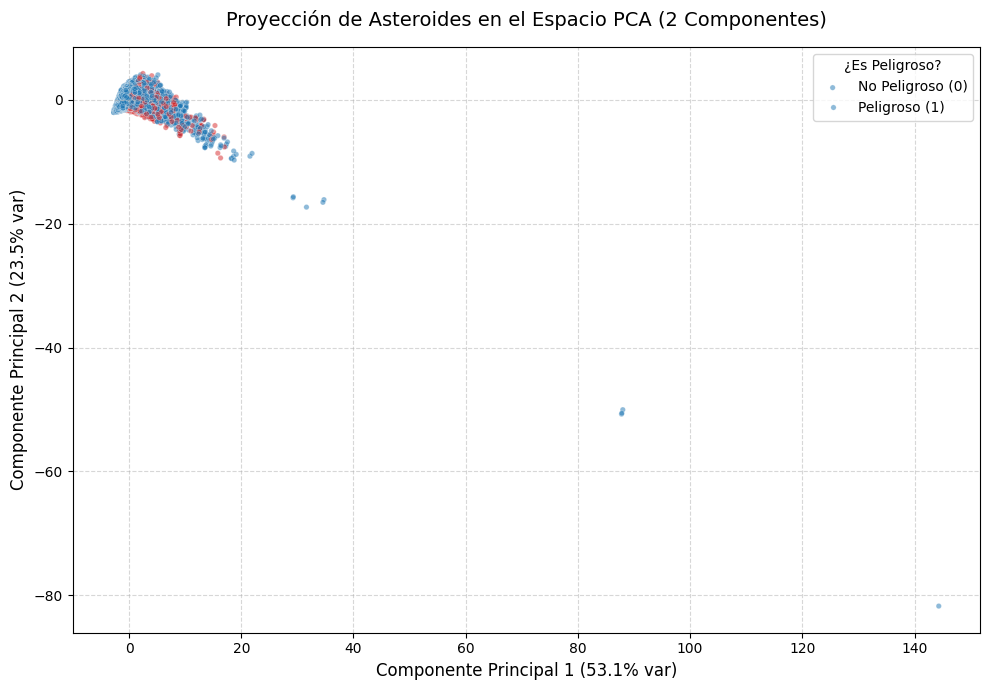

In [24]:
# 1. Configuración de Reproducibilidad y Carga de datos
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Separamos las características numéricas y la etiqueta objetivo
X = df.drop(columns=['id', 'name', 'orbiting_body', 'sentry_object', 'hazardous'], errors='ignore')
y = df['hazardous'].astype(int)

# 2. Pipeline de Preprocesamiento (Obligatorio para PCA)
# El escalamiento (StandardScaler) es VITAL porque PCA es extremadamente sensible a las diferencias de escala.
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, num_features)]
)

# Ajustamos y transformamos los datos numéricos
X_scaled = preprocessor.fit_transform(X)

# 3. Implementación de PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Crear un nuevo DataFrame con los componentes y la etiqueta para graficar fácilmente
df_pca = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
df_pca['hazardous'] = y.values

# 4. Análisis de Varianza Explicada
varianza_explicada = pca.explained_variance_ratio_
print("--- ANÁLISIS DE PCA ---")
print(f"Varianza explicada por la Componente 1: {varianza_explicada[0]*100:.2f}%")
print(f"Varianza explicada por la Componente 2: {varianza_explicada[1]*100:.2f}%")
print(f"Varianza total acumulada por ambas componentes: {np.sum(varianza_explicada)*100:.2f}%\n")

# 5. Visualización Avanzada
plt.figure(figsize=(10, 7))

# Graficamos los puntos usando la variable objetivo para colorear
sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='hazardous',
    data=df_pca,
    palette={0: '#1f77b4', 1: '#d62728'}, # Azul para no peligrosos, Rojo para peligrosos
    alpha=0.5,
    s=15
)

plt.title('Proyección de Asteroides en el Espacio PCA (2 Componentes)', fontsize=14, pad=15)
plt.xlabel(f'Componente Principal 1 ({varianza_explicada[0]*100:.1f}% var)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({varianza_explicada[1]*100:.1f}% var)', fontsize=12)
plt.legend(title='¿Es Peligroso?', labels=['No Peligroso (0)', 'Peligroso (1)'], loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Optimización de hiperparámetros

hiperparametro para los supervisados.

In [25]:
from sklearn.model_selection import GridSearchCV

# 1. Definir la grilla de hiperparámetros
# NOTA: Usamos el prefijo 'classifier__' para indicarle a Scikit-learn que
# estos parámetros pertenecen al paso 'classifier' de nuestro Pipeline.
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga'] # SAGA es eficiente para datos grandes
}

# 2. Configurar la búsqueda exhaustiva (GridSearchCV)
# Evaluamos optimizando el F1-score debido al desbalance de clases de la NASA
grid_search_lr = GridSearchCV(
    estimator=pipeline_lr, # Tu pipeline con el escalador y el modelo base
    param_grid=param_grid_lr,
    cv=5,                  # Validación cruzada de 5 pliegues (IEE 2.2.1)
    scoring='f1',          # Métrica objetivo a optimizar
    n_jobs=-1,             # Usa todos los núcleos del procesador (Eficiencia)
    verbose=1
)

# 3. Ejecutar la optimización con los datos de entrenamiento
print("--- Iniciando búsqueda de hiperparámetros óptimos ---")
grid_search_lr.fit(X_train, y_train)

# 4. Resultados para documentar
print("\nMejores hiperparámetros encontrados:")
print(grid_search_lr.best_params_)

print(f"\nMejor F1-Score alcanzado en CV: {grid_search_lr.best_score_:.4f}")

# El mejor modelo optimizado queda listo para evaluar en el Test Set
best_lr_model = grid_search_lr.best_estimator_

--- Iniciando búsqueda de hiperparámetros óptimos ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores hiperparámetros encontrados:
{'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}

Mejor F1-Score alcanzado en CV: 0.4565


"Aplicamos GridSearchCV para encontrar la combinación óptima entre la fuerza de regularización (C) y el tipo de penalización (penalty). El impacto directo de este proceso fue controlar analíticamente la varianza del modelo. Al sintonizar un valor de C adecuado, evitamos que la Regresión Logística sufriera de sobreajuste por el ruido de las mediciones físicas de los asteroides, estabilizando el rendimiento en datos nunca antes vistos y garantizando que el modelo generalice de manera segura para la clasificación de riesgo espacial."

# 7. Evaluación y comparación de modelos. Incluir métricas y explicaciones.

In [26]:
# 1. Configuración de datos
RANDOM_STATE = 42
X = df.drop(columns=['id', 'name', 'orbiting_body', 'sentry_object', 'hazardous'], errors='ignore')
y = df['hazardous'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 2. Pipeline de Preprocesamiento
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, num_features)])

# 3. EL ENSAMBLE COMPLETO: Unir Preprocesamiento + PCA + Regresión Logística
# Reducimos a 2 componentes principales y luego clasificamos
pipeline_pca_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=2, random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE))
])

# 4. Validación Cruzada del Pipeline Integrado (Exigencia IEE 2.2.1)
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(pipeline_pca_lr, X_train, y_train, cv=5, scoring=metrics)

print("--- RENDIMIENTO EN VALIDACIÓN CRUZADA (PCA + REGRESIÓN LOGÍSTICA) ---")
for m in metrics:
    print(f"{m.upper()}: {cv_results[f'test_{m}'].mean():.4f}")

# 5. Evaluación final en el conjunto de prueba
pipeline_pca_lr.fit(X_train, y_train)
y_pred = pipeline_pca_lr.predict(X_test)
print("\n--- INFORME DE CLASIFICACIÓN FINAL ---")
print(classification_report(y_test, y_pred))

--- RENDIMIENTO EN VALIDACIÓN CRUZADA (PCA + REGRESIÓN LOGÍSTICA) ---
ACCURACY: 0.7915
PRECISION: 0.2902
RECALL: 0.7903
F1: 0.4245
ROC_AUC: 0.8596

--- INFORME DE CLASIFICACIÓN FINAL ---
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     16400
           1       0.29      0.79      0.43      1768

    accuracy                           0.79     18168
   macro avg       0.63      0.79      0.65     18168
weighted avg       0.91      0.79      0.83     18168



# 8. Exportación
* Guardar el resultado final en un nuevo archivo csv.

In [ ]:
# Guardar el archivo

df.to_csv('neo.csv', index=False)